In [1]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [5]:
import os
import cv2
import torch
import numpy as np
from ultralytics import YOLO
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from google.colab.patches import cv2_imshow

# --- Load models once globally ---
YOLO_MODEL_PATH = '/content/best (1).pt'
CLASSIFIER_MODEL_PATH = "/content/best_model_f1.keras"

yolo_model = YOLO(YOLO_MODEL_PATH)

# Explicitly set the device for TensorFlow model to CPU
with tf.device('/CPU:0'):
    classifier_model = tf.keras.models.load_model(CLASSIFIER_MODEL_PATH)

# --- Label Maps ---
FACE_CLASSES = {
    0: 'Unknown', 1: 'Iqra Aziz', 2: 'Hamuyun Saeed', 3: 'Atif Aslam', 4: 'Fahad Mustafa', 5: 'Fawad Khan',
    6: 'Hamza Ali Abbasi', 7: 'Hania Amir', 8: 'Qubra Khan', 9: 'Maira Khan', 10: 'Naseem Shah', 11: 'Noman Ijaz',
    12: 'Neelam Muneer', 13: 'Ramsha Khan', 14: 'Sajal Ali', 15: 'Shaheen Shah Afridi'
}
gender_map = {0: "Female", 1: "Male"}
GENDER_COLORS = {0: (0, 255, 0), 1: (255, 0, 0)}  # Green: Female, Blue: Male

# --- Detection + Classification ---
def detect_and_classify_faces(image_path, output_path='annotated_output.jpg'):
    IMAGE_SIZE = (224, 224)

    # Read and prepare image
    img_cv = cv2.imread(image_path)
    if img_cv is None:
        raise FileNotFoundError(f"❌ Could not read image: {image_path}")

    img_height, img_width = img_cv.shape[:2]
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    # YOLO gender detection
    results = yolo_model.predict(img_rgb, conf=0.1, iou=0.5, imgsz=1024, verbose=False)
    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        print("❌ No faces detected.")
        return

    print(f"\n✅ Detected {len(boxes)} face(s):\n")

    # Loop through detections
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box.xyxy.cpu().numpy()[0])
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img_width, x2), min(img_height, y2)

        gender = int(box.cls.cpu().numpy()[0])
        confidence = float(box.conf.cpu().numpy()[0])
        color = GENDER_COLORS.get(gender, (255, 255, 255))

        # Crop and preprocess face
        face = img_rgb[y1:y2, x1:x2]
        if face.size == 0:
            continue

        face_resized = cv2.resize(face, IMAGE_SIZE)
        face_input = np.expand_dims(face_resized, axis=0)
        face_preprocessed = resnet_preprocess_input(face_input)

        # Identity classification
        # Ensure classification is done on CPU
        with tf.device('/CPU:0'):
            prediction = classifier_model.predict(face_preprocessed, verbose=0)
        pred_class = int(np.argmax(prediction[0]))
        identity = FACE_CLASSES.get(pred_class, 'Unknown')
        gender_text = gender_map.get(gender, 'Unknown')

        # Final label
        label_text = f"{gender_text}, {identity}, {confidence:.2f}"
        print(f"Face {i+1}: {label_text}")

        # Draw label background
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale, thickness, margin = 0.5, 1, 4
        (text_w, text_h), _ = cv2.getTextSize(label_text, font, font_scale, thickness)
        text_x = max(min(x1, img_width - text_w - margin), margin)
        text_y = y1 - margin if y1 - text_h - margin > margin else y2 + text_h + margin
        text_y = min(text_y, img_height - margin)

        cv2.rectangle(img_cv, (text_x - margin, text_y - text_h - margin),
                             (text_x + text_w + margin, text_y + margin), color, -1)
        cv2.putText(img_cv, label_text, (text_x, text_y), font, font_scale, (255, 255, 255), thickness)
        cv2.rectangle(img_cv, (x1, y1), (x2, y2), color, 1)

    # Save and show
    cv2.imwrite(output_path, img_cv)
    print(f"\n📸 Saved annotated image to: {output_path}")
    cv2_imshow(img_cv)


✅ Detected 3 face(s):

Face 1: Female, Hania Amir, 0.86
Face 2: Female, Iqra Aziz, 0.78
Face 3: Female, Maira Khan, 0.75

📸 Saved annotated image to: annotated_output.jpg


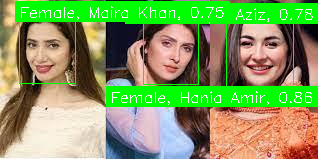

In [6]:
detect_and_classify_faces('/content/images.jpg')


✅ Detected 7 face(s):

Face 1: Female, Unknown, 0.82
Face 2: Male, Hamuyun Saeed, 0.81
Face 3: Male, Unknown, 0.72
Face 4: Male, Unknown, 0.57
Face 5: Female, Shaheen Shah Afridi, 0.54
Face 6: Female, Maira Khan, 0.38
Face 7: Male, Qubra Khan, 0.19

📸 Saved annotated image to: annotated_output.jpg


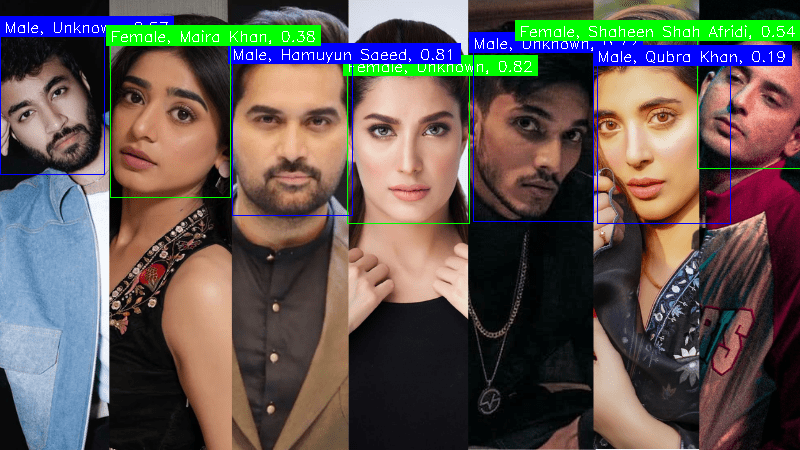

In [8]:
detect_and_classify_faces('/content/08141522d6a7f85.png')